## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Carga y Procesamiento de Datos

In [2]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")
print(f"El dataset cuenta con {df.shape[1]} features")

Total de observaciones: 79
Rango temporal: 2025-01-02 a 2025-04-30
El dataset cuenta con 61 features


### 2.1. Limpieza de valores nulos

In [3]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

Filas con NA en 'merval': 0


### 2.2. Separación de variables

In [4]:
# Separación de variables predictoras y objetivo
y = df["merval"]
X = df.drop(columns=["merval"])

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (79, 60)
Shape de y: (79,)


## 3. División Train-Test

In [5]:
# División temporal (80-20)
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (63, 60)
Test shape: (16, 60)


## 4. Feature Selection - Selección de Top Features

Para abordar el problema de dimensionalidad y reducir el ruido para el LSTM, seleccionamos las top 12 features más importantes usando Random Forest.

In [6]:
# Entrenar un modelo simple para obtener importancia de features
# Usamos Random Forest con configuración conservadora
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train, y_train)

# Obtener importancia de features
feature_importance = pd.Series(
    rf_selector.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features más importantes:")
print(feature_importance.head(15))


Top 15 features más importantes:
merval_cierre                      0.181234
merval_apertura_std20              0.174297
tc_mayorista_std20                 0.119429
emae_tendencia_ciclo_ma_5          0.117334
badlar_ma_5                        0.071848
tc_minorista_std20                 0.060031
merval_cierre_std20                0.041002
tasa_prestamos_personales_ma_3     0.034160
badlar_ma_3                        0.023849
emae_tendencia_ciclo_lag2          0.020620
tasa_prestamos_personales_ma_5     0.019483
inflacion_hp_ema20                 0.015673
merval_maximo                      0.015642
tasa_prestamos_personales_std20    0.013007
m1_std20                           0.009247
dtype: float64


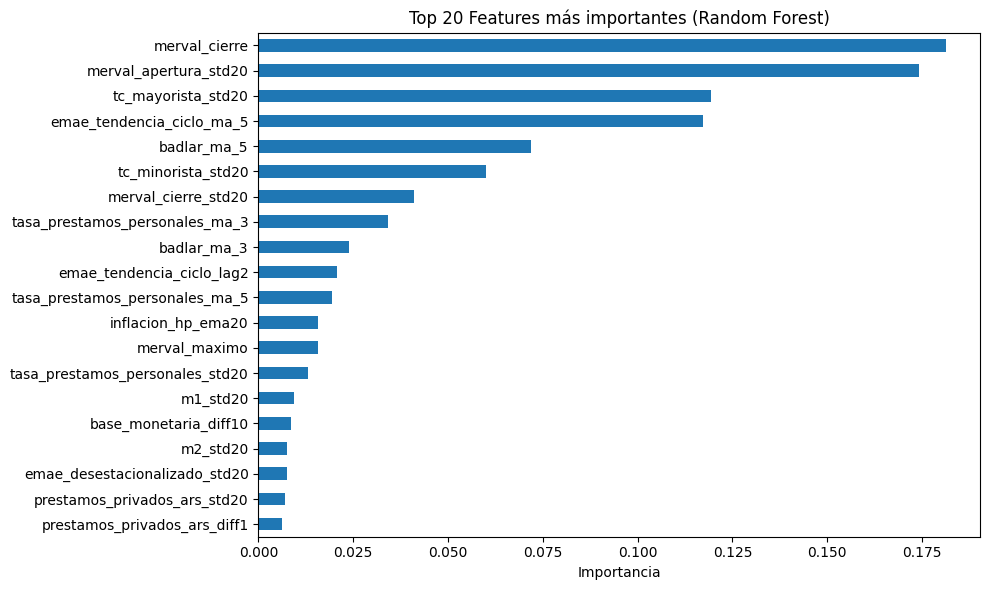

In [7]:
# Visualizar importancia de features
plt.figure(figsize=(10, 6))
feature_importance.head(20).sort_values(ascending=True).plot(kind='barh')
plt.title('Top 20 Features más importantes (Random Forest)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [8]:
# Seleccionar top N features
N_FEATURES = 12  # Cambiar a 15 si se desea probar con más features

selected_features = feature_importance.head(N_FEATURES).index.tolist()

print(f"\nSeleccionadas {N_FEATURES} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

# Filtrar datasets
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

print(f"\nNuevo train shape: {X_train_fs.shape}")
print(f"Nuevo test shape: {X_test_fs.shape}")
print(f"\nNuevo ratio observaciones/features: {X_train_fs.shape[0] / X_train_fs.shape[1]:.2f}")


Seleccionadas 12 features:
1. merval_cierre
2. merval_apertura_std20
3. tc_mayorista_std20
4. emae_tendencia_ciclo_ma_5
5. badlar_ma_5
6. tc_minorista_std20
7. merval_cierre_std20
8. tasa_prestamos_personales_ma_3
9. badlar_ma_3
10. emae_tendencia_ciclo_lag2
11. tasa_prestamos_personales_ma_5
12. inflacion_hp_ema20

Nuevo train shape: (63, 12)
Nuevo test shape: (16, 12)

Nuevo ratio observaciones/features: 5.25


### 4.1. Normalización de features seleccionadas

In [9]:
# Convertir a numpy arrays
X_train_np = X_train_fs.values
X_test_np = X_test_fs.values
y_train_np = y_train.values
y_test_np = y_test.values

# Normalizar features (importante para redes neuronales)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_np)
X_test_scaled = scaler_X.transform(X_test_np)
y_train_scaled = scaler_y.fit_transform(y_train_np.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_np.reshape(-1, 1)).flatten()

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (63, 12)
X_test_scaled shape: (16, 12)


## 5. Creación de Secuencias Temporales

In [10]:
def create_sequences(X, y, time_steps=3):
    """
    Crea secuencias temporales para LSTM.
    
    Args:
        X: Features de entrada
        y: Variable objetivo
        time_steps: Número de pasos temporales a considerar
    
    Returns:
        X_seq: Secuencias de features (samples, time_steps, features)
        y_seq: Valores objetivo correspondientes
    """
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    
    return np.array(X_seq), np.array(y_seq)

In [11]:
# Crear secuencias temporales
TIME_STEPS = 3  # Reducir a 3 días para maximizar muestras disponibles

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print(f"Train sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")

Train sequences shape: (60, 3, 12)
Test sequences shape: (13, 3, 12)


## 6. Construcción del Modelo LSTM

In [12]:
# Arquitectura del modelo - Simplificada para dataset pequeño con feature selection
model = Sequential([
    # Capa LSTM con pocas unidades (menos features = menos parámetros necesarios)
    LSTM(16, return_sequences=False, input_shape=(TIME_STEPS, N_FEATURES)),
    Dropout(0.4),  # Dropout alto para regularización agresiva
    
    Dense(4, activation='relu'),  # Capa densa pequeña
    Dropout(0.3),
    
    Dense(1)
])

# Compilar modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,929 (7.54 KB)

 Trainable params: 1,929 (7.54 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento del Modelo

In [13]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

# Entrenar modelo
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=200,
    batch_size=8,
    validation_split=0.25,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 1.0721 - mae: 0.8579 - val_loss: 0.7786 - val_mae: 0.6177 - learning_rate: 3.0000e-04
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1320 - mae: 0.8497 - val_loss: 0.7555 - val_mae: 0.6038 - learning_rate: 3.0000e-04
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7103 - mae: 0.7009 - val_loss: 0.7349 - val_mae: 0.5919 - learning_rate: 3.0000e-04
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8340 - mae: 0.7564 - val_loss: 0.7163 - val_mae: 0.5822 - learning_rate: 3.0000e-04
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6546 - mae: 0.6864 - val_loss: 0.6996 - val_mae: 0.5729 - learning_rate: 3.0000e-04
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4749 - mae: 0.5556 - val_loss: 0.6862 - val_mae: 0.5646 - learning_rate: 3.0000e-04
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7597 - mae: 0.7197 - val_loss: 0.6735 - val_mae: 0.5567 - learning_rate: 3.0000e-0

### 7.1. Visualización del entrenamiento

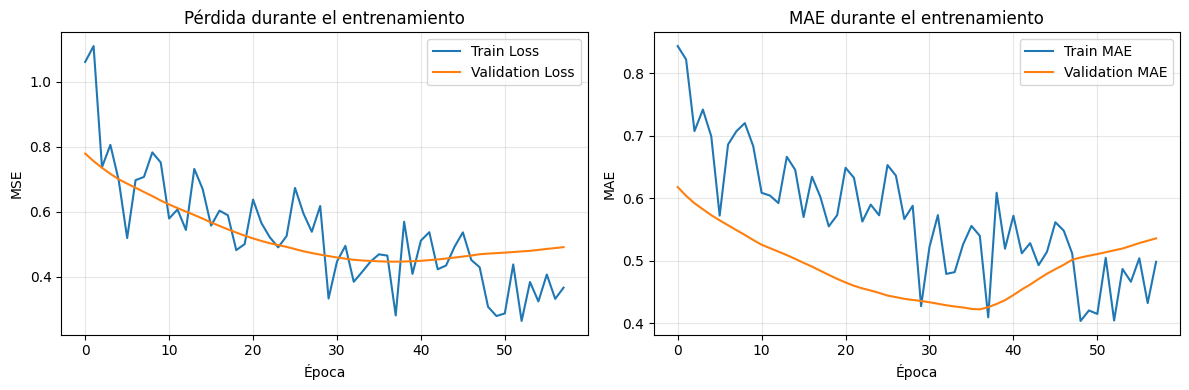

In [14]:
# Gráfico de pérdida durante entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluación en Test Set

### 8.1. Métricas de desempeño

In [15]:
# Predicciones en escala normalizada
y_pred_scaled = model.predict(X_test_seq)

# Desnormalizar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_original = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Calcular métricas
rmse = root_mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)
rmse_rel = rmse / y_test_original.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 228286.7826
Holdout R²:   -8.5460
Error relativo (holdout): 10.38%


### 8.2. Visualización de predicciones

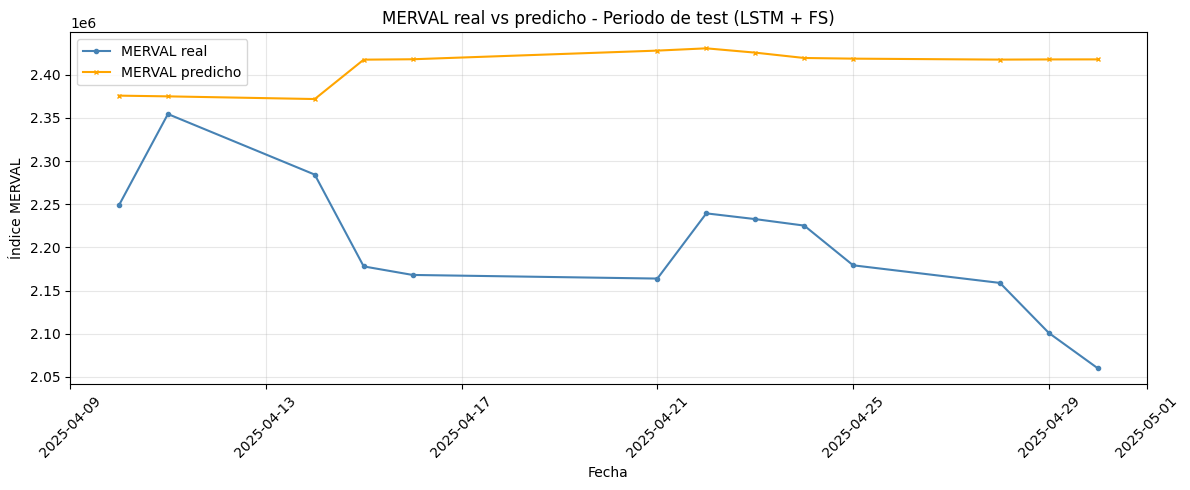

In [16]:
# Crear índices para graficar
test_indices = df.index[train_size + TIME_STEPS:]

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_indices.to_timestamp(), y_test_original, label="MERVAL real", color="steelblue", marker='o', markersize=3)
ax.plot(test_indices.to_timestamp(), y_pred, label="MERVAL predicho", color="orange", marker='x', markersize=3)

ax.set_title("MERVAL real vs predicho - Periodo de test (LSTM + FS)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3. Análisis de residuales

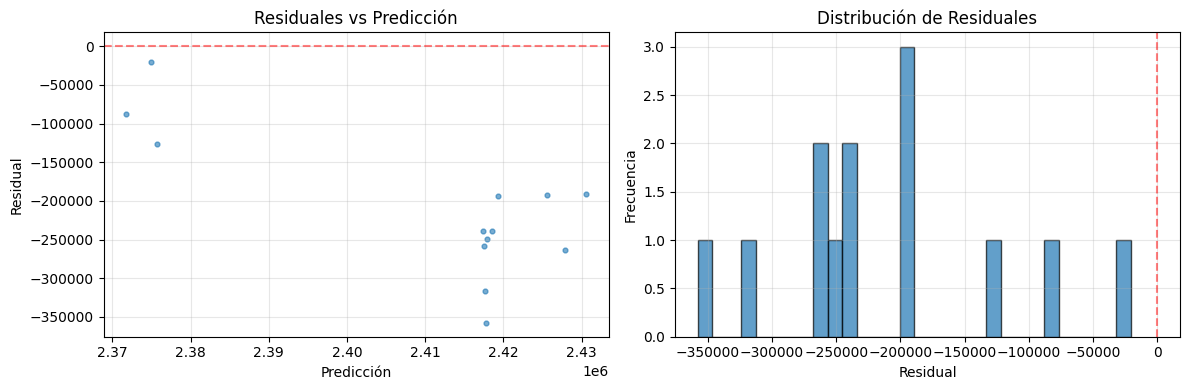

In [17]:
res = y_test_original - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuales vs Predicción
axes[0].scatter(y_pred, res, s=12, alpha=0.6)
axes[0].axhline(0, ls="--", color='red', alpha=0.5)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuales vs Predicción")
axes[0].grid(True, alpha=0.3)

# Histograma de residuales
axes[1].hist(res, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, ls="--", color='red', alpha=0.5)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuales")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Conclusiones

Este modelo LSTM utiliza **feature selection** para reducir las variables de 60 a 12, abordando el problema de dimensionalidad y reduciendo el ruido en los datos.

### Resultados Obtenidos

```
RMSE Test:     228,287
R²:            -8.55
Error relativo: 10.38%
```

### Comparación con LSTM Base (sin FS)

**LSTM base** (60 features): RMSE 231,359, R² -8.80, Error 10.52%  
**LSTM + FS** (12 features): RMSE 228,287, R² -8.55, Error 10.38%

**Mejora marginal**: ~1.3% reducción en RMSE

La feature selection produjo una **mejora muy leve** en el desempeño del LSTM:
- RMSE mejoró ~3,000 puntos (~1.3%)
- R² mejoró marginalmente de -8.80 a -8.55
- Error relativo bajó de 10.52% a 10.38%

### Análisis de Resultados

**¿Por qué la mejora fue tan pequeña?**

1. **Limitación fundamental de datos**: Con solo 60 secuencias de entrenamiento, reducir de 60 a 12 features no resuelve el problema principal
   - LSTM requiere típicamente 5,000+ secuencias para aprender patrones robustos
   - El ratio observaciones/parámetros mejoró (de 12:1 a 31:1) pero sigue siendo insuficiente

2. **LSTM procesa todas las features por igual**: A diferencia de modelos de árbol (Random Forest, LightGBM) que pueden ignorar features irrelevantes, LSTM procesa todas las variables en cada timestep
   - Con 60 features ruidosas, el modelo aprende patrones espurios
   - Con 12 features más limpias, hay menos ruido pero también menos información útil

3. **Arquitectura simplificada ayudó levemente**: Reducir parámetros de ~5,000 a ~1,900 permitió mejor regularización
   - Dropout 0.4/0.3 más efectivo con modelo más pequeño
   - Menos tendencia a memorizar el conjunto de entrenamiento

### Features Seleccionadas

Las 12 features seleccionadas por Random Forest fueron principalmente:
- **Variables MERVAL**: merval_cierre, merval_apertura_std20, merval_cierre_std20
- **Tipo de cambio**: tc_mayorista_std20, tc_minorista_std20 (volatilidades)
- **Indicadores macro**: emae_tendencia_ciclo_ma_5, emae_tendencia_ciclo_lag2
- **Tasas de interés**: badlar_ma_5, badlar_ma_3, tasa_prestamos_personales_ma_3
- **Inflación**: inflacion_hp_ema20

El selector priorizó:
- ✓ Volatilidades (std20) que capturan incertidumbre del mercado
- ✓ Medias móviles (ma_3, ma_5) que suavizan series temporales
- ✓ Variables rezagadas que respetan causalidad temporal

### Veredicto Final

**Feature selection NO resolvió el problema del LSTM.**

Aunque redujo ruido y complejidad del modelo, la mejora fue **marginal** (~1.3%) porque:
- La limitación principal es la **cantidad absoluta de datos** (60 secuencias), no la dimensionalidad
- R² sigue siendo fuertemente negativo (-8.55), indicando que el modelo es **peor que predecir la media**
- Error relativo del 10.38% es **inaceptable** para aplicaciones financieras

**El modelo sigue siendo completamente inviable para predicción práctica del MERVAL.**

Para que un LSTM funcione aceptablemente se necesitaría:
- Mínimo 500-1,000 secuencias (vs. 60 actuales)
- Idealmente 5,000+ secuencias para aprendizaje robusto
- O bien, usar modelos más simples (ARIMA logró RMSE de 176,055 con el mismo dataset)